# AskMyBookmark — Orchestrator Pattern POC

This notebook builds a **LangGraph orchestrator** (supervisor pattern) for searching starred GitHub repositories.

## Architecture

The key insight guiding this design: **keyword extraction → synonym generation is always a fixed,
sequential pipeline** — there is no routing decision to make. Exposing them as separate agent tools
would let the LLM call them out of order or skip one. Instead they form a deterministic
**Query Prep sub-workflow** that always runs first.

The **Supervisor** is the only true agent: it reads the (now-enriched) state and decides which
retriever to invoke.

```
User Query
    │
    ▼
┌─────────────────────────────────────┐
│         Query Prep (deterministic)  │
│  keyword_extractor → synonym_gen    │
└─────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────┐
│   Supervisor Agent (LLM router)     │
│   Decides: lexical | semantic | both│
└─────────────────────────────────────┘
    │            │                 │
    ▼            ▼                 ▼
 bm25_search  vector_search  ensemble_search
    │            │            (RRF BM25+dense)
    │            │                 │
    └────────────┴─────────────────┘
                 │
                 ▼
           merge_results
                 │
                 ▼
          generate_answer
                 │
                 ▼
              Response
```

## Routing Heuristic

| Route | When to use |
|---|---|
| `lexical` | Query contains specific repo names, exact tech terms, programming languages |
| `semantic` | Conceptual or exploratory queries where meaning > exact wording |
| `both` | Complex queries that benefit from both exact-term and semantic matching |

## State Shape

| Field | Populated by | Used by |
|---|---|---|
| `query` | user input | `keyword_extractor`, `vector_search`, `generate_answer` |
| `keywords` | `keyword_extractor` | `synonym_generator`, `bm25_search` |
| `expansions` | `synonym_generator` | (debugging / display) |
| `bm25_terms` | `synonym_generator` | `bm25_search` |
| `route` | `supervisor` | conditional edge routing |
| `bm25_results` | `bm25_search` / `ensemble_search` | `merge_results` |
| `vector_results` | `vector_search` | `merge_results` |
| `merged_results` | `merge_results` | `generate_answer` |
| `answer` | `generate_answer` | end user |


## 1. Imports & Environment Setup

In [1]:
import os
import pickle
import re
import uuid
from functools import partial
from typing import List, Dict, Any, Literal

import nest_asyncio
import numpy as np
import pandas as pd
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from pydantic import BaseModel, Field, ConfigDict
from textacy import preprocessing
from typing import TypedDict

from langchain.retrievers import EnsembleRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langgraph.graph import StateGraph, START, END
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from searcharray import SearchArray

nest_asyncio.apply()

# load environment variables — try notebooks/.env first (local dev), then root .env
for _env_path in ["notebooks/.env", ".env"]:
    if os.path.exists(_env_path):
        load_dotenv(_env_path)
        break

# download NLTK data if not already present
for _pkg in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(_pkg, quiet=True)

print("Imports OK")

Imports OK


## 2. Shared State

All nodes read from and write to a single `OrchestratorState` dict.  LangGraph merges the
partial dicts returned by each node into this shared state, so each node only needs to
return the keys it modifies.

In [2]:
class OrchestratorState(TypedDict):
    # ── Input ────────────────────────────────────────────────────────────────
    query: str                     # original user query (verbatim)

    # ── Query Prep (populated by deterministic sub-workflow) ─────────────────
    keywords: List[str]            # signal-bearing terms extracted from query
    expansions: List[Dict]         # per-keyword synonym objects (for inspection)
    bm25_terms: List[str]          # flat synonym list used to expand BM25 query

    # ── Supervisor ───────────────────────────────────────────────────────────
    route: str                     # "lexical" | "semantic" | "both"

    # ── Retrieval results ────────────────────────────────────────────────────
    bm25_results: List[Document]
    vector_results: List[Document]
    merged_results: List[Document]

    # ── Final output ─────────────────────────────────────────────────────────
    answer: str

## 3. Query Prep — Deterministic Sub-Workflow

These two nodes **always run sequentially** before the supervisor sees the state.  There is no
routing decision here — the sequence is fixed in the graph edges.

### Why this is a workflow, not agent tools

If `keyword_extractor` and `synonym_generator` were exposed as separate tools to the supervisor,
an LLM could call them out of order, forget one, or call `synonym_generator` directly on raw
natural language.  Making them deterministic graph nodes eliminates that class of failure entirely.

### Design note: keyword extraction is idempotent on keyword-only queries

The extractor strips conversational filler and returns signal-bearing terms.  For a query that is
*already* just keywords (e.g. `"pytorch transformers"`), the extractor returns them unchanged.
This means we never need a separate "is this natural language?" classifier — just always run both
nodes.

In [3]:
# ── Structured output schemas ─────────────────────────────────────────────────

class KeywordExtractionOutput(BaseModel):
    keywords: List[str] = Field(
        description="Keywords extracted from the user query suitable for BM25 lexical search."
    )


class KeywordExpansion(BaseModel):
    keyword: str = Field(description="The original extracted keyword.")
    synonyms: List[str] = Field(
        description="Synonyms and closely related technical terms for this keyword "
                    "in the context of GitHub repos."
    )


class SynonymExpansionOutput(BaseModel):
    expansions: List[KeywordExpansion] = Field(
        description="Per-keyword synonym expansions."
    )


# ── System prompts ─────────────────────────────────────────────────────────────

KEYWORD_EXTRACTION_SYSTEM_PROMPT = """\
You are a search query keyword extractor for AskMyBookmark -- a conversational search \
assistant that helps people search through their starred GitHub repos. \
When given a user query, extract only the keywords that carry lexical search signal: \
repo names, technology names, programming languages, domain terms, and action verbs. \
Strip conversational filler, pronouns, and stopwords.\
Ignore extracting words related to repositories, repos, or GitHub in general.\
Ignore extracting words related to favorites or starred if related to repositories or GitHub in general.\
"""

SYNONYM_EXPANSION_SYSTEM_PROMPT = """\
You are a search term expander for AskMyBookmark -- a search assistant over starred GitHub repos. \
Given a list of search keywords, generate relevant synonyms and closely related technical terms \
for each keyword in the context of software, science, technology and GitHub repositories. \
Avoid duplicating the original keywords in the synonyms list.\
"""

# ── LLMs with structured output ───────────────────────────────────────────────

_base_llm = ChatOpenAI(model="gpt-4o-mini")
_keyword_extractor_llm = _base_llm.with_structured_output(KeywordExtractionOutput)
_synonym_generator_llm = _base_llm.with_structured_output(SynonymExpansionOutput)


# ── Graph nodes ───────────────────────────────────────────────────────────────

def keyword_extractor(state: OrchestratorState) -> dict:
    """Extract signal-bearing keywords from the raw user query."""
    response: KeywordExtractionOutput = _keyword_extractor_llm.invoke([
        SystemMessage(content=KEYWORD_EXTRACTION_SYSTEM_PROMPT),
        HumanMessage(content=state["query"]),
    ])
    return {"keywords": response.keywords}


def synonym_generator(state: OrchestratorState) -> dict:
    """Expand each keyword with synonyms; flatten into a single BM25 term list."""
    response: SynonymExpansionOutput = _synonym_generator_llm.invoke([
        SystemMessage(content=SYNONYM_EXPANSION_SYSTEM_PROMPT),
        HumanMessage(content=str(state["keywords"])),
    ])
    bm25_terms = [syn for exp in response.expansions for syn in exp.synonyms]
    return {
        "expansions": [exp.model_dump() for exp in response.expansions],
        "bm25_terms": bm25_terms,
    }


print("Query prep nodes defined")

Query prep nodes defined


## 4. Data Loading & Index Building

We reuse the exact same retriever setup from `retrievers.ipynb`:

- **`MultiMatchBM25Retriever`** — a custom LangChain retriever wrapping SearchArray's per-field
  BM25 with boost weights (`repo` × 3, `topics` × 2, `description` × 1.5, `content` × 1.0).
- **Qdrant in-memory dense retriever** — OpenAI `text-embedding-3-small` embeddings stored in
  a local Qdrant instance, queried with cosine similarity.

Both retrievers are built once at notebook startup and shared across graph invocations.

In [4]:
# ── Text pre-processing (mirrors retrievers.ipynb / ask_my_bookmark.py) ────────

MAX_CHARACTERS = 30_000
NAMESPACE = uuid.NAMESPACE_URL


def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax while keeping inner text and emojis."""
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"`([^`]+)`", r"\1", text)
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(*, unicode_form: str = "NFC"):
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


_normalize_text = make_normalize_text_pipeline()


def repo_to_uuid(repo_name: str) -> str:
    return str(uuid.uuid5(NAMESPACE, repo_name))


def normalize_docs(docs: List[Dict[str, Any]]) -> str:
    content_str = "".join(doc["content"] + "\n\n" for doc in docs)
    truncated = content_str[:MAX_CHARACTERS] if len(content_str) > MAX_CHARACTERS else content_str
    return _normalize_text(truncated)


def preprocess_text(text: str | None) -> List[str]:
    """Tokenizer used by SearchArray BM25 — lowercase, remove stopwords, lemmatize."""
    if text is None:
        return []
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in tokens]


print("Text preprocessing helpers defined")

Text preprocessing helpers defined


In [5]:
# ── MultiMatchBM25Retriever (from retrievers.ipynb) ────────────────────────────

def multi_match_search(
    query: str,
    df: pd.DataFrame,
    columns: List[str],
    boosts: Dict[str, float] | None = None,
) -> pd.DataFrame:
    """BM25 multi-field search with per-field boost weights and dismax scoring."""
    if boosts is None:
        boosts = {}
    boost_values = {col: boosts.get(col, 1.0) for col in columns}

    tokenized_queries = {
        col: df[col].array.tokenizer(query)
        for col in columns
    }

    field_scores = {
        col: np.asarray([df[col].array.score(term) for term in tokenized_queries[col]])
             * boost_values[col]
        for col in columns
    }

    num_terms = max((len(s) for s in field_scores.values()), default=0)
    if num_terms == 0:
        result = df.copy()
        result["score"] = 0.0
        return result

    best_term_scores = []
    for term_idx in range(num_terms):
        term_scores = [
            field_scores[col][term_idx]
            for col in columns
            if term_idx < len(field_scores[col])
        ]
        best_term_scores.append(np.max(term_scores, axis=0))

    result = df.copy()
    result["score"] = np.sum(best_term_scores, axis=0)
    return result.sort_values("score", ascending=False)


class MultiMatchBM25Retriever(BaseRetriever):
    """LangChain-compatible retriever wrapping SearchArray multi-field BM25."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    search_df: pd.DataFrame
    columns: List[str]
    boosts: Dict[str, float]
    k: int = 10

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> List[Document]:
        results = multi_match_search(
            query=query,
            df=self.search_df,
            columns=self.columns,
            boosts=self.boosts,
        )
        top_k = results[results["score"] > 0].head(self.k)
        return [
            Document(
                page_content=row["content"],
                metadata={
                    "id":          row["id"],
                    "repo":        row["repo"],
                    "description": row["description"],
                    "topics":      row["topics"],
                    "score":       float(row["score"]),
                },
            )
            for _, row in top_k.iterrows()
        ]


print("MultiMatchBM25Retriever defined")

MultiMatchBM25Retriever defined


In [6]:
# ── Load cached GitHub data ───────────────────────────────────────────────────

with open("../data/cached/github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

print(f"Loaded {len(starred_repo_data)} starred repos")

# ── Build per-field search DataFrame ─────────────────────────────────────────

search_df = pd.DataFrame([
    {
        "id":          repo_to_uuid(repo["repo"]),
        "repo":        repo["repo"],
        "description": repo.get("description") or "",
        "topics":      " ".join(repo.get("topics", [])),
        "content":     f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
    }
    for repo in starred_repo_data
])

# index each field with SearchArray for BM25 scoring
search_df["repo_idx"]        = SearchArray.index(search_df["repo"],        tokenizer=preprocess_text)
search_df["description_idx"] = SearchArray.index(search_df["description"], tokenizer=preprocess_text)
search_df["topics_idx"]      = SearchArray.index(search_df["topics"],      tokenizer=preprocess_text)
search_df["content_idx"]     = SearchArray.index(search_df["content"],     tokenizer=preprocess_text)

print(f"search_df built: {len(search_df)} rows")

Loaded 2049 starred repos
2026-03-16 20:04:32,953 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-16 20:04:32,954 - searcharray.indexing - INFO - 0 Batch Start tokenization
2026-03-16 20:04:32,954 - searcharray.indexing - INFO - Tokenizing 2049 documents
2026-03-16 20:04:34,499 - searcharray.indexing - INFO - Tokenization -- vstacking
2026-03-16 20:04:34,499 - searcharray.indexing - INFO - Tokenization -- DONE
2026-03-16 20:04:34,500 - searcharray.indexing - INFO - Inverting docs->terms
2026-03-16 20:04:34,500 - searcharray.indexing - INFO - Encoding positions to bit array
2026-03-16 20:04:34,502 - searcharray.indexing - INFO - Batch tokenization complete
2026-03-16 20:04:34,503 - searcharray.indexing - INFO - (main thread) Processing 1 batch results
2026-03-16 20:04:34,504 - searcharray.indexing - INFO - Indexing from tokenization complete
2026-03-16 20:04:34,505 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-16 20:04:34,505 - searcharray.ind

In [7]:
# ── Compute curated-list BM25 score (for document metadata) ──────────────────
#
# Repos that are themselves "awesome lists" get a boosted score stored in
# metadata so the answer generator can note it if relevant.

CURATED_QUERY = "awesome curated lists"
curated_results = multi_match_search(
    query=CURATED_QUERY,
    df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={"repo_idx": 3.0, "topics_idx": 2.0, "description_idx": 1.5, "content_idx": 1.0},
)
curated_score_by_id = dict(
    zip(curated_results["id"], curated_results["score"].astype(float))
)

# ── Build LangChain Document objects (shared by both retrievers) ──────────────

documents = [
    Document(
        page_content=f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
        metadata={
            "id":                (id_ := repo_to_uuid(repo["repo"])),
            "repo":              repo["repo"],
            "description":       repo.get("description") or "",
            "topics":            repo.get("topics", []),
            "language":          repo.get("language"),
            "doc_source":        repo.get("doc_source"),
            "stars":             repo.get("stars"),
            "url":               repo.get("url"),
            "curated_list_bm25": curated_score_by_id.get(id_, 0.0),
        },
    )
    for repo in starred_repo_data
]

# ── MultiMatchBM25 retriever ──────────────────────────────────────────────────

bm25_retriever = MultiMatchBM25Retriever(
    search_df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={
        "repo_idx":        3.0,
        "topics_idx":      2.0,
        "description_idx": 1.5,
        "content_idx":     1.0,
    },
    k=10,
)

# ── Qdrant in-memory dense retriever ─────────────────────────────────────────

print("Building Qdrant index — this may take a minute...")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="ask_my_bookmark",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="ask_my_bookmark",
    embedding=embeddings,
)
vector_store.add_documents(documents)
dense_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# ── Ensemble retriever (RRF fusion of BM25 + dense) ──────────────────────────
#
# EnsembleRetriever combines results from both retrievers using Reciprocal Rank
# Fusion (RRF). Unlike running them sequentially and merging manually, RRF
# re-ranks by inverse rank position, giving a principled combined ranking.
# Used by the `ensemble_search` node when the supervisor routes to "both".

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
)

print("All retrievers ready (BM25, dense, ensemble)")

Building Qdrant index — this may take a minute...
All retrievers ready (BM25, dense, ensemble)


## 5. Search Nodes

Three search nodes cover the three routing outcomes:

| Node | Retriever | Query input |
|---|---|---|
| `bm25_search` | `MultiMatchBM25Retriever` | `keywords` + `bm25_terms` joined as one string |
| `vector_search` | Qdrant dense retriever | `query` (original — best for embeddings) |
| `ensemble_search` | `EnsembleRetriever` (BM25 + dense via RRF) | expanded BM25 query for lexical leg; `query` for dense leg |

The BM25 expanded query combines the original extracted keywords with all generated synonyms.
This is the point where synonym expansion pays off — the synonyms are injected directly into
the lexical search rather than being used as a semantic fallback.

### Why `EnsembleRetriever` for "both" instead of running them manually?

`EnsembleRetriever` uses **Reciprocal Rank Fusion (RRF)** under the hood: it scores each
document as the sum of `1 / (rank + k)` across all retrievers, then re-ranks by that fused
score. This is more principled than a simple concatenation + dedup, and matches the approach
used in `retrievers.ipynb`.

> **Note:** `EnsembleRetriever` passes the same query string to all its child retrievers.
> For the `ensemble_search` node we pass the **expanded BM25 query** (keywords + synonyms)
> as a deliberate trade-off: the BM25 leg gets the term expansion benefit, while the dense
> leg is robust enough that the extra keywords in the query string do not hurt embedding quality.

In [8]:
def _build_bm25_query(state: OrchestratorState) -> str:
    """Join extracted keywords + synonyms into a single expanded query string for BM25."""
    all_terms = state["keywords"] + state["bm25_terms"]
    return " ".join(all_terms)


def bm25_search(state: OrchestratorState) -> dict:
    """Run lexical BM25 search using the keyword-expanded query."""
    expanded_query = _build_bm25_query(state)
    results = bm25_retriever.invoke(expanded_query)
    return {"bm25_results": results, "vector_results": []}


def vector_search(state: OrchestratorState) -> dict:
    """Run semantic vector search using the original user query."""
    results = dense_retriever.invoke(state["query"])
    return {"bm25_results": [], "vector_results": results}


def ensemble_search(state: OrchestratorState) -> dict:
    """Run EnsembleRetriever (RRF fusion of BM25 + dense) on the expanded query.

    Passes the keyword-expanded query (keywords + synonyms) to EnsembleRetriever
    so the BM25 leg gets full term expansion benefit. RRF then re-ranks results
    from both legs by inverse rank position, yielding a principled fused ranking.
    The fused results are stored in bm25_results; vector_results is left empty
    since merge_results will pass merged_results straight through from bm25_results.
    """
    expanded_query = _build_bm25_query(state)
    results = ensemble_retriever.invoke(expanded_query)
    # Store in bm25_results — merge_results deduplicates bm25 + vector, so placing
    # the already-fused RRF results here means they flow through unchanged.
    return {"bm25_results": results, "vector_results": []}


print("Search nodes defined")

Search nodes defined


## 6. Supervisor — LLM Router

The supervisor is the only agent in this graph.  It reads the enriched state (original query +
extracted keywords) and decides which search strategy to use via **structured output**.

Using structured output (`RouteDecision`) instead of a free-form message guarantees the node
always writes a valid `route` value that the conditional edge can act on — no string parsing needed.

The supervisor has access to `keywords` (not just the raw query) so it can make a more informed
decision: if the extracted keywords are sparse or very broad, `semantic` is likely better;
if they are precise technical terms, `lexical` will score well.

In [9]:
# ── Routing decision schema ───────────────────────────────────────────────────

class RouteDecision(BaseModel):
    route: Literal["lexical", "semantic", "both"] = Field(
        description=(
            "Search strategy to use. "
            "'lexical' for exact tech terms / repo names; "
            "'semantic' for conceptual or exploratory queries; "
            "'both' for complex queries that benefit from both."
        )
    )
    reasoning: str = Field(
        description="One sentence explaining why this route was chosen."
    )


SUPERVISOR_SYSTEM_PROMPT = """\
You are the search router for AskMyBookmark, an assistant that searches a user's starred GitHub repos.

Given a user query and its extracted keywords, decide which search strategy to use:

- "lexical"  : Query contains specific repo names, exact technology names, programming languages,
               or precise technical identifiers that will score well with BM25 term matching.
- "semantic" : Query is conceptual, exploratory, or uses high-level descriptions where the meaning
               matters more than exact keyword overlap.
- "both"     : Query is complex or ambiguous and would benefit from combining exact-term and
               semantic search results.

When in doubt, prefer "both".
"""

_supervisor_llm = ChatOpenAI(model="gpt-4o-mini").with_structured_output(RouteDecision)


def supervisor(state: OrchestratorState) -> dict:
    """LLM-based router: reads query + extracted keywords, writes route decision."""
    user_message = (
        f"Query: {state['query']}\n"
        f"Extracted keywords: {state['keywords']}"
    )
    decision: RouteDecision = _supervisor_llm.invoke([
        SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
        HumanMessage(content=user_message),
    ])
    print(f"[supervisor] route={decision.route!r}  reason: {decision.reasoning}")
    return {"route": decision.route}


def route_after_supervisor(state: OrchestratorState) -> str:
    """Conditional edge function — returns the node name to visit next."""
    route_map = {
        "lexical":  "bm25_search",
        "semantic": "vector_search",
        "both":     "ensemble_search",
    }
    return route_map[state["route"]]


print("Supervisor node defined")

Supervisor node defined


## 7. Merge & Answer Generation

### `merge_results`

Combines BM25 and vector results using a simple **Reciprocal Rank Fusion (RRF)**-style merge:
deduplicate by repo name while preserving the first-seen rank.  BM25 results are listed first
(they are more precise for expanded queries), then any vector-only results are appended.

### `generate_answer`

Uses the same RAG system prompt from `app/ask_my_bookmark.py` — grounding the LLM strictly
in the retrieved repository context, not its general knowledge of GitHub.

In [10]:
# ── Merge node ────────────────────────────────────────────────────────────────

def merge_results(state: OrchestratorState) -> dict:
    """
    Deduplicate and merge BM25 + vector results.

    Strategy: iterate BM25 results first (precise expanded-keyword matches),
    then append any vector-only results not already seen.  This gives a merged
    list that favours lexical precision while filling in semantic coverage.
    """
    seen_repos: set = set()
    merged: List[Document] = []

    for doc in (state["bm25_results"] + state["vector_results"]):
        repo = doc.metadata.get("repo")
        if repo and repo not in seen_repos:
            seen_repos.add(repo)
            merged.append(doc)

    return {"merged_results": merged}


# ── RAG system prompt (from ask_my_bookmark.py) ────────────────────────────────

RAG_SYSTEM_PROMPT = """You are AskMyBookmark, a personal research assistant with access to the user's GitHub starred repositories.

Your job is to help the user discover, recall, and explore repositories they have bookmarked on GitHub. You answer questions by reasoning over the retrieved repository context provided to you — not from your general knowledge of what exists on GitHub.

**Ground rules:**
- Only surface repositories that appear in the retrieved context below. Do not invent or suggest repositories that are not present in the context.
- If no retrieved repositories are relevant to the query, say so honestly and suggest the user try rephrasing or broadening their search.
- You may use your general knowledge to explain a topic or technology, but all repository recommendations must come exclusively from the retrieved context.

**When presenting results:**
- Always include the repository's full name (Repo) as a markdown link to its GitHub URL: [Repo](URL)
- Include a brief description of what the repo does (from the description and topics fields), written in your own words if the original description is terse or absent.
- Explain in 1–2 sentences *why* this repository is relevant to the user's query — this is the most important part.
- Group or rank results by relevance if there are several.
- If useful, note the primary programming language, star count, or topics to help the user evaluate the match.
"""

RAG_HUMAN_PROMPT_TEMPLATE = """User query: {query}

Retrieved repositories:
{context}
"""

_rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(RAG_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template(RAG_HUMAN_PROMPT_TEMPLATE),
])

_answer_llm = ChatOpenAI(model="gpt-4o-mini")
_rag_chain = _rag_prompt | _answer_llm


def _format_context(docs: List[Document]) -> str:
    """Serialise retrieved docs into the context block passed to the LLM."""
    parts = []
    for doc in docs:
        m = doc.metadata
        parts.append(
            f"Repo: {m.get('repo', 'unknown')}\n"
            f"URL: {m.get('url', '')}\n"
            f"Description: {m.get('description', '')}\n"
            f"Topics: {', '.join(m.get('topics', []))}\n"
            f"Language: {m.get('language', '')}\n"
            f"Stars: {m.get('stars', '')}\n"
            "---"
        )
    return "\n".join(parts)


def generate_answer(state: OrchestratorState) -> dict:
    """Generate a grounded answer from the merged retrieved documents."""
    context = _format_context(state["merged_results"])
    response = _rag_chain.invoke({"query": state["query"], "context": context})
    return {"answer": response.content}


print("Merge + answer nodes defined")

Merge + answer nodes defined


## 8. Graph Assembly

Wire all nodes together into a single `StateGraph`:

1. Fixed edges: `START → keyword_extractor → synonym_generator → supervisor`
2. Conditional edge from `supervisor` using `route_after_supervisor` to choose one of
   `bm25_search`, `vector_search`, or `ensemble_search`
3. All three search nodes converge on `merge_results → generate_answer → END`

In [11]:
def build_orchestrator_graph():
    graph = StateGraph(OrchestratorState)

    # ── Register nodes ────────────────────────────────────────────────────────
    graph.add_node("keyword_extractor", keyword_extractor)
    graph.add_node("synonym_generator", synonym_generator)
    graph.add_node("supervisor",        supervisor)
    graph.add_node("bm25_search",       bm25_search)
    graph.add_node("vector_search",     vector_search)
    graph.add_node("ensemble_search",   ensemble_search)
    graph.add_node("merge_results",     merge_results)
    graph.add_node("generate_answer",   generate_answer)

    # ── Deterministic Query Prep chain ────────────────────────────────────────
    graph.add_edge(START,                "keyword_extractor")
    graph.add_edge("keyword_extractor",  "synonym_generator")
    graph.add_edge("synonym_generator",  "supervisor")

    # ── Conditional routing from supervisor ───────────────────────────────────
    graph.add_conditional_edges(
        "supervisor",
        route_after_supervisor,
        {
            "bm25_search":     "bm25_search",
            "vector_search":   "vector_search",
            "ensemble_search": "ensemble_search",
        },
    )

    # ── All search nodes converge on merge ────────────────────────────────────
    graph.add_edge("bm25_search",     "merge_results")
    graph.add_edge("vector_search",   "merge_results")
    graph.add_edge("ensemble_search", "merge_results")
    graph.add_edge("merge_results",   "generate_answer")
    graph.add_edge("generate_answer", END)

    return graph.compile()


orchestrator = build_orchestrator_graph()
print("Graph compiled successfully")

Graph compiled successfully


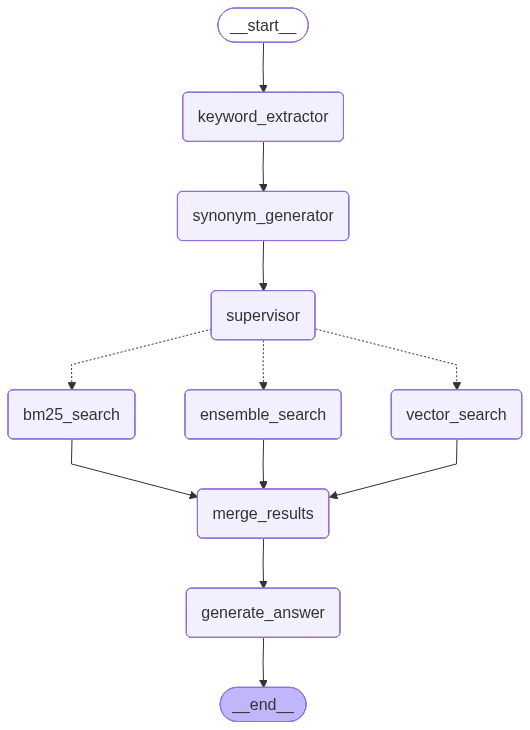

In [12]:
from IPython.display import Image, display

display(Image(orchestrator.get_graph().draw_mermaid_png()))

## 9. Test Queries

Three representative queries that exercise different routing paths:

| Query | Expected route | Why |
|---|---|---|
| Natural language (deep learning) | `both` or `lexical` | Specific tech domain + clear keywords |
| Keyword-only ("pytorch transformers") | `lexical` | Already precise terms, no filler |
| Conceptual ("repos that help me understand probability") | `semantic` | Broad concept, embeddings fit better |

A helper function `run_query` prints the intermediate state so we can inspect what each
stage produced.

In [13]:
def run_query(query: str) -> dict:
    """Run a query through the orchestrator and display intermediate state."""
    print("=" * 70)
    print(f"QUERY: {query}")
    print("=" * 70)

    initial_state: OrchestratorState = {
        "query":          query,
        "keywords":       [],
        "expansions":     [],
        "bm25_terms":     [],
        "route":          "",
        "bm25_results":   [],
        "vector_results": [],
        "merged_results": [],
        "answer":         "",
    }

    result = orchestrator.invoke(initial_state)

    print(f"\n--- Keywords extracted: {result['keywords']}")
    print(f"--- BM25 synonym terms : {result['bm25_terms'][:5]} ... ({len(result['bm25_terms'])} total)")
    print(f"--- Route chosen       : {result['route']}")
    print(f"--- BM25 hits          : {len(result['bm25_results'])}")
    print(f"--- Vector hits        : {len(result['vector_results'])}")
    print(f"--- Merged results     : {len(result['merged_results'])} unique repos")
    print()
    print("ANSWER:")
    print(result["answer"])
    print()

    return result

In [14]:
# Test 1 — Natural language query (expects 'both' or 'lexical')
result1 = run_query("What are some top deep learning libraries I have starred?")

QUERY: What are some top deep learning libraries I have starred?
[supervisor] route='semantic'  reason: The query is exploratory, asking for information about categories of libraries rather than specific repo names or terms.

--- Keywords extracted: ['deep learning', 'libraries']
--- BM25 synonym terms : ['neural networks', 'machine learning', 'artificial intelligence', 'supervised learning', 'unsupervised learning'] ... (20 total)
--- Route chosen       : semantic
--- BM25 hits          : 0
--- Vector hits        : 10
--- Merged results     : 10 unique repos

ANSWER:
Here are some prominent deep learning libraries from your starred repositories:

1. **[BVLC/caffe](https://github.com/BVLC/caffe)**  
   Caffe is a fast open framework for deep learning that allows users to build and deploy deep learning models efficiently. With 34,780 stars, it's one of the most popular deep learning libraries available, making it a significant resource for anyone working in the field.

2. **[activeloopa

In [15]:
# Test 2 — Keyword-only query (expects 'lexical')
result2 = run_query("pytorch transformers")

QUERY: pytorch transformers
[supervisor] route='lexical'  reason: The query contains specific technology names ('pytorch', 'transformers') which are precise identifiers suitable for exact matching.

--- Keywords extracted: ['pytorch', 'transformers']
--- BM25 synonym terms : ['torch', 'deep learning framework', 'neural network library', 'tensor library', 'GPU acceleration'] ... (18 total)
--- Route chosen       : lexical
--- BM25 hits          : 10
--- Vector hits        : 0
--- Merged results     : 10 unique repos

ANSWER:
Here are some relevant repositories related to PyTorch and transformers that you may find interesting:

1. **[codertimo/BERT-pytorch](https://github.com/codertimo/BERT-pytorch)**
   - This repository provides an implementation of Google's BERT (Bidirectional Encoder Representations from Transformers) using PyTorch.
   - It's particularly relevant for anyone looking to work with transformer-based natural language processing models in PyTorch.

2. **[NVIDIA-Merlin/Tra

In [16]:
# Test 3 — Conceptual / exploratory query (expects 'semantic' or 'both')
result3 = run_query("Do I have repos that help me understand probability and Bayesian reasoning?")

QUERY: Do I have repos that help me understand probability and Bayesian reasoning?
[supervisor] route='semantic'  reason: The query is conceptual and exploratory, focusing on understanding concepts rather than specific repos or technologies.

--- Keywords extracted: ['probability', 'Bayesian', 'reasoning']
--- BM25 synonym terms : ['likelihood', 'chance', 'odds', 'statistical potential', 'randomness'] ... (24 total)
--- Route chosen       : semantic
--- BM25 hits          : 0
--- Vector hits        : 10
--- Merged results     : 10 unique repos

ANSWER:
Here are several repositories that can help you understand probability and Bayesian reasoning:

1. **[pymc-devs/pymc-resources](https://github.com/pymc-devs/pymc-resources)**  
   This repository contains educational resources related to PyMC, a tool for Bayesian inference and statistics. It is particularly relevant for learning Bayesian concepts in the context of data analysis and data science, making it a great starting point for your 